# Data Visualization Scripts

## Imports

In [181]:
import pandas as pd
import seaborn as sns
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

## Load data

In [155]:
path = "data/"
prefix = "2026-"

target_csv_files = glob.glob(os.path.join(path, f"{prefix}*.csv"))

df_list = []
for csv_file in target_csv_files:
   df = pd.read_csv(csv_file, encoding="utf-8", on_bad_lines="skip")
   df_list.append(df)

df_all_data = pd.concat(df_list, ignore_index=True)
df_all_data.head(n=5)

,time,battery_percent,current_window,num_chrome_tabs,active_chrome_tab_url
0,2026-03-23T03:32:00-0400,96%,Google Chrome,27.0,https://**REDACTED_GITHUB_LINK**.com/oce-asset...
1,2026-03-23T05:43:56-0400,96%,Google Chrome,27.0,https://**REDACTED_GITHUB_LINK**.com/oce-asset...
2,2026-03-23T05:44:00-0400,96%,Google Chrome,27.0,https://**REDACTED_GITHUB_LINK**.com/oce-asset...
3,2026-03-23T07:46:00-0400,96%,Google Chrome,27.0,https://**REDACTED_GITHUB_LINK**.com/oce-asset...
4,2026-03-23T08:51:16-0400,95%,Google Chrome,27.0,https://**REDACTED_GITHUB_LINK**.com/oce-asset...


## Data cleaning

In [156]:
df_all_data["time"] = pd.to_datetime(df_all_data["time"])
df_all_data["hour"] = df_all_data["time"].dt.hour

# Filtering data to only ones between 8 AM and 6 PM
df_all_data_cleaned = df_all_data[df_all_data["time"].dt.hour.between(8, 18)]

print(
    df_all_data_cleaned["hour"].value_counts().sort_index()
    )

hour
8      13
9     219
10    268
11    249
12    138
13    197
14    214
15    255
16    218
17     29
18     24
Name: count, dtype: int64


In [157]:
# Removing the % suffix in battery percent column
df_all_data_cleaned["battery_percent"] = (
    df_all_data_cleaned["battery_percent"].str.replace("%", "", regex=False)
    .astype(int)
)

In [158]:
df_all_data_cleaned.head(n=5)

,time,battery_percent,current_window,num_chrome_tabs,active_chrome_tab_url,hour
4,2026-03-23 08:51:16-04:00,95,Google Chrome,27.0,https://**REDACTED_GITHUB_LINK**.com/oce-asset...,8
5,2026-03-23 08:52:00-04:00,95,Google Chrome,27.0,https://**REDACTED_GITHUB_LINK**.com/oce-asset...,8
6,2026-03-23 08:54:00-04:00,95,Slack,27.0,https://pygithub.readthedocs.io/en/stable/apis...,8
7,2026-03-23 08:56:00-04:00,95,Slack,30.0,https://pygithub.readthedocs.io/en/stable/apis...,8
8,2026-03-23 08:58:01-04:00,94,Google Chrome,35.0,https://www.google.com/search?q=windows+list+l...,8


## Charts

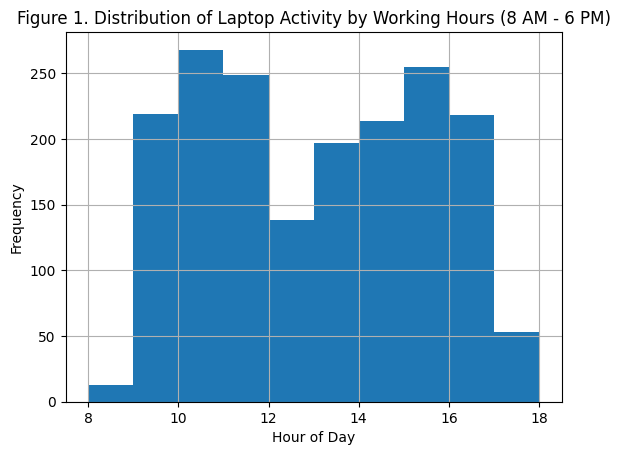

In [187]:
df_all_data_cleaned["time"].dt.hour.hist(bins=10)

plt.xlabel("Hour of Day")
plt.ylabel("Frequency")
plt.title("Figure 1. Distribution of Laptop Activity by Working Hours (8 AM - 6 PM)")

plt.show()

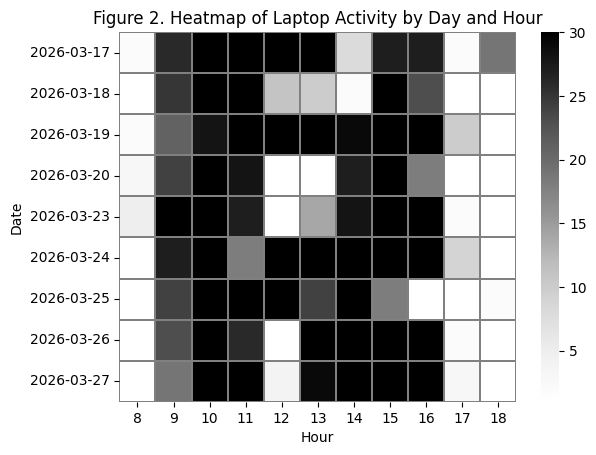

In [189]:
df_all_data_cleaned["hour"] = df_all_data_cleaned["time"].dt.hour
df_all_data_cleaned["day"] = df_all_data_cleaned["time"].dt.date

pivot = df_all_data_cleaned.pivot_table(index="day", columns="hour", aggfunc="size")

sns.heatmap(pivot, cmap="Greys", cbar=True, linewidths=0.1, linecolor="gray")
plt.title("Figure 2. Heatmap of Laptop Activity by Day and Hour")
plt.xlabel("Hour")
plt.ylabel("Date")

plt.show()

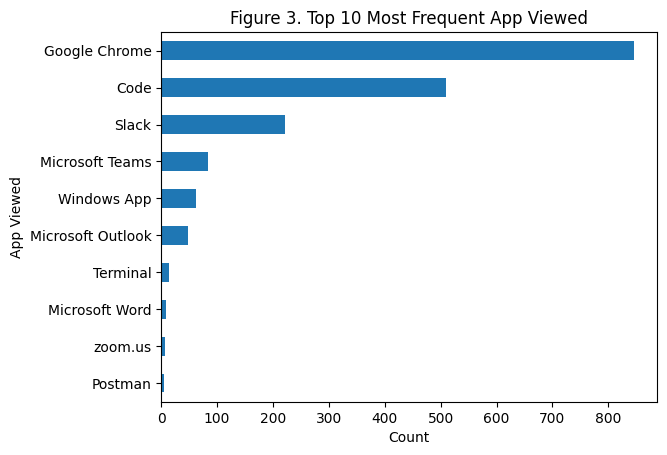

In [190]:
df_all_data_cleaned["current_window"].value_counts().head(10).sort_values().plot(kind="barh")

plt.xlabel("Count")
plt.ylabel("App Viewed")
plt.title("Figure 3. Top 10 Most Frequent App Viewed")

plt.show()

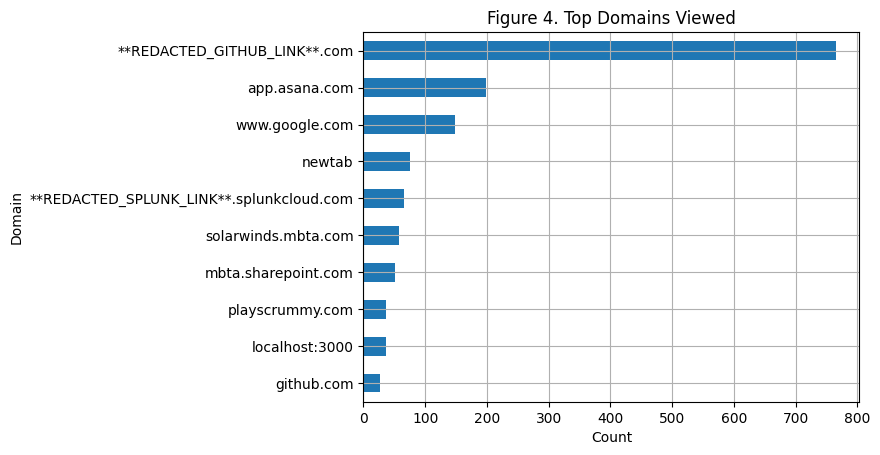

In [191]:
from urllib.parse import urlparse

df_all_data_cleaned["domain"] = df_all_data_cleaned["active_chrome_tab_url"].dropna().apply(
    lambda x: urlparse(x).netloc
)

df_all_data_cleaned["domain"].value_counts().head(10).sort_values().plot(kind="barh")

plt.title('Figure 4. Top Domains Viewed')
plt.xlabel('Count')
plt.ylabel('Domain')
plt.grid(True)

In [161]:
# Get "window_change" value (i.e. when the current window I'm viewing is different than the previous)
df_all_data_cleaned["window_change"] = df_all_data_cleaned["current_window"] != df_all_data_cleaned["current_window"].shift(1)
df_all_data_cleaned.head(5)

,time,battery_percent,current_window,num_chrome_tabs,active_chrome_tab_url,hour,window_change
4,2026-03-23 08:51:16-04:00,95,Google Chrome,27.0,https://**REDACTED_GITHUB_LINK**.com/oce-asset...,8,True
5,2026-03-23 08:52:00-04:00,95,Google Chrome,27.0,https://**REDACTED_GITHUB_LINK**.com/oce-asset...,8,False
6,2026-03-23 08:54:00-04:00,95,Slack,27.0,https://pygithub.readthedocs.io/en/stable/apis...,8,True
7,2026-03-23 08:56:00-04:00,95,Slack,30.0,https://pygithub.readthedocs.io/en/stable/apis...,8,False
8,2026-03-23 08:58:01-04:00,94,Google Chrome,35.0,https://www.google.com/search?q=windows+list+l...,8,True


In [166]:
# Summarize attention span by 30 minute bins
df_all_data_cleaned.index = df_all_data_cleaned["time"]
resampled_df = df_all_data_cleaned["window_change"].resample("30min").sum()
resampled_df

time
2026-03-17 08:30:00-04:00    2
2026-03-17 09:00:00-04:00    4
2026-03-17 09:30:00-04:00    7
2026-03-17 10:00:00-04:00    5
2026-03-17 10:30:00-04:00    2
                            ..
2026-03-27 16:00:00-04:00    3
2026-03-27 16:30:00-04:00    2
2026-03-27 17:00:00-04:00    0
2026-03-27 17:30:00-04:00    0
2026-03-27 18:00:00-04:00    0
Freq: 30min, Name: window_change, Length: 500, dtype: int64

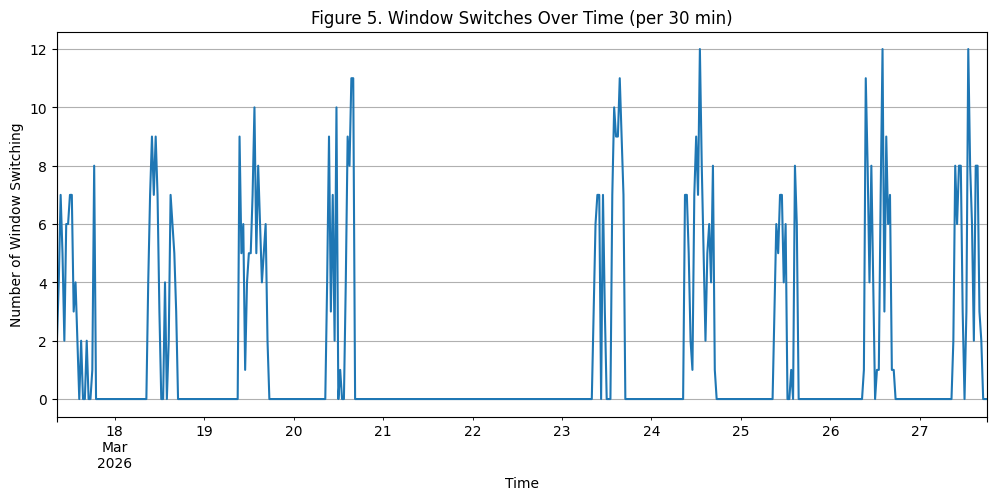

In [192]:
plt.figure(figsize=(12, 5))
resampled_df.plot()
plt.title("Figure 5. Window Switches Over Time (per 30 min)")
plt.xlabel("Time")
plt.ylabel("Number of Window Switching")
plt.grid(True)
plt.show()

In [164]:
# View plot as "per day" charts

# Excluding weekend dates w/ no activity
exclude_dates = [
    pd.to_datetime('2026-03-21').date(),
    pd.to_datetime('2026-03-22').date()
]

mask = ~pd.Series(resampled_df.index.date).isin(exclude_dates).values
filtered_df = resampled_df[mask]

daily_groups = filtered_df.groupby(filtered_df.index.date)

for date, group in daily_groups:
    print(f"Date: {date}")
    print(group.head(2))

Date: 2026-03-17
time
2026-03-17 08:30:00-04:00    2
2026-03-17 09:00:00-04:00    4
Name: window_change, dtype: int64
Date: 2026-03-18
time
2026-03-18 00:00:00-04:00    0
2026-03-18 00:30:00-04:00    0
Name: window_change, dtype: int64
Date: 2026-03-19
time
2026-03-19 00:00:00-04:00    0
2026-03-19 00:30:00-04:00    0
Name: window_change, dtype: int64
Date: 2026-03-20
time
2026-03-20 00:00:00-04:00    0
2026-03-20 00:30:00-04:00    0
Name: window_change, dtype: int64
Date: 2026-03-23
time
2026-03-23 00:00:00-04:00    0
2026-03-23 00:30:00-04:00    0
Name: window_change, dtype: int64
Date: 2026-03-24
time
2026-03-24 00:00:00-04:00    0
2026-03-24 00:30:00-04:00    0
Name: window_change, dtype: int64
Date: 2026-03-25
time
2026-03-25 00:00:00-04:00    0
2026-03-25 00:30:00-04:00    0
Name: window_change, dtype: int64
Date: 2026-03-26
time
2026-03-26 00:00:00-04:00    0
2026-03-26 00:30:00-04:00    0
Name: window_change, dtype: int64
Date: 2026-03-27
time
2026-03-27 00:00:00-04:00    0
202

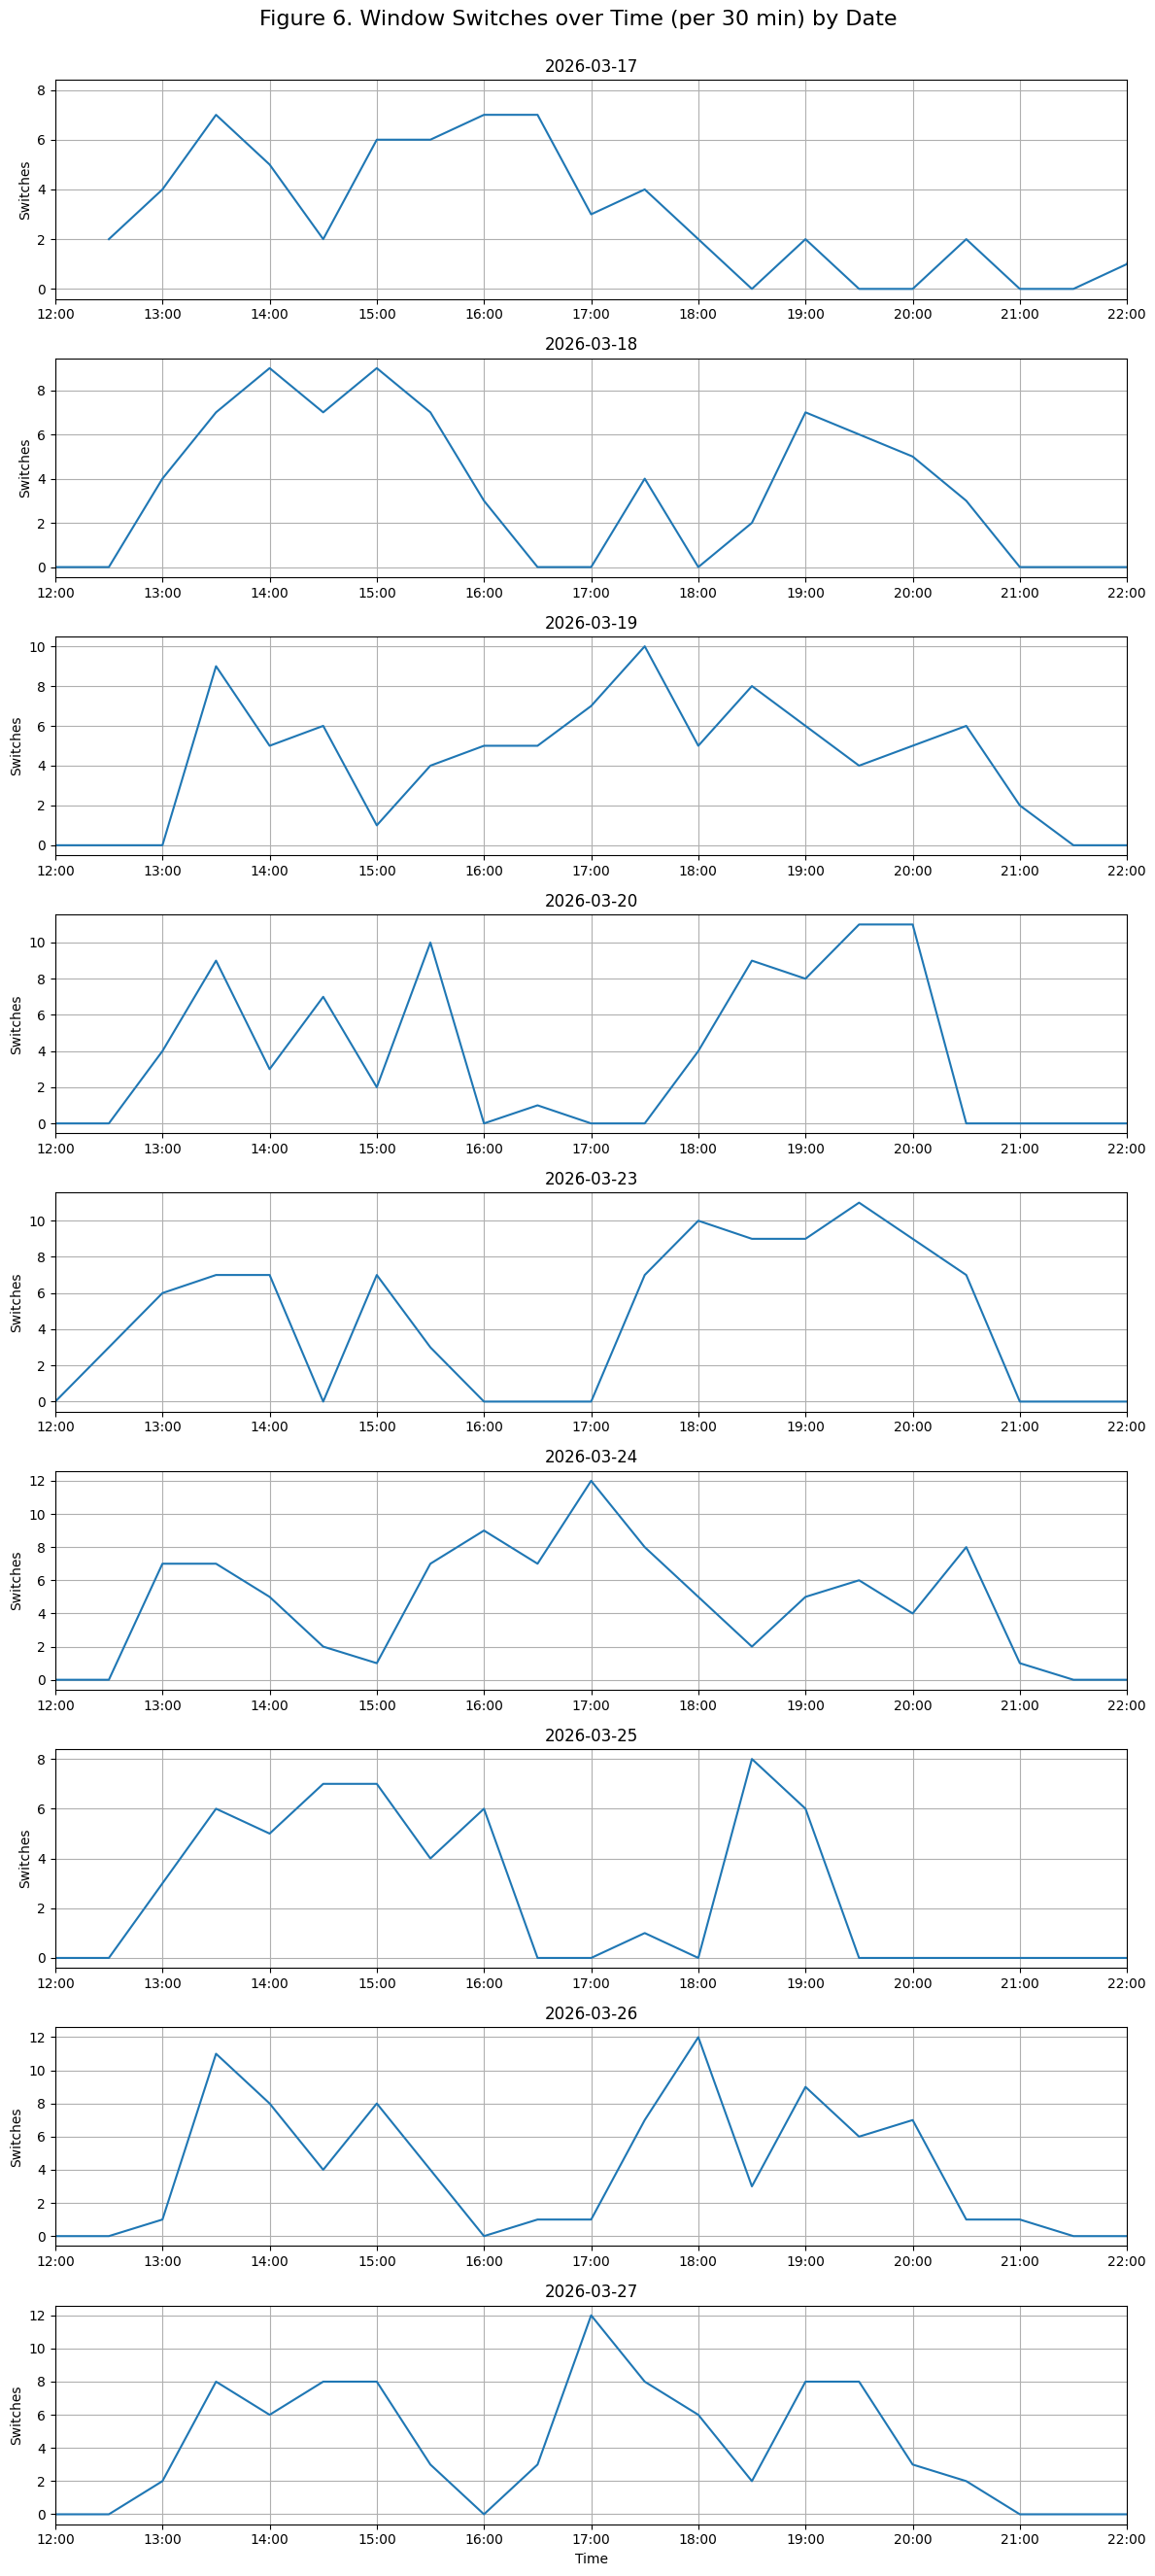

In [201]:
num_days = len(daily_groups)
fig, axes = plt.subplots(num_days, 1, figsize=(12, 3 * num_days), sharex=False)

for ax, (day, series) in zip(axes, daily_groups):
    ax.plot(series.index, series.values)
    ax.set_title(day)
    ax.set_ylabel('Switches')
    ax.grid(True)

    # constrain to that day's working hours
    start = series.index.min().replace(hour=8, minute=0, second=0)
    end = series.index.min().replace(hour=18, minute=0, second=0)
    ax.set_xlim(start, end)

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))

fig.suptitle("Figure 6. Window Switches over Time (per 30 min) by Date", fontsize=16)
plt.xlabel("Time")
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

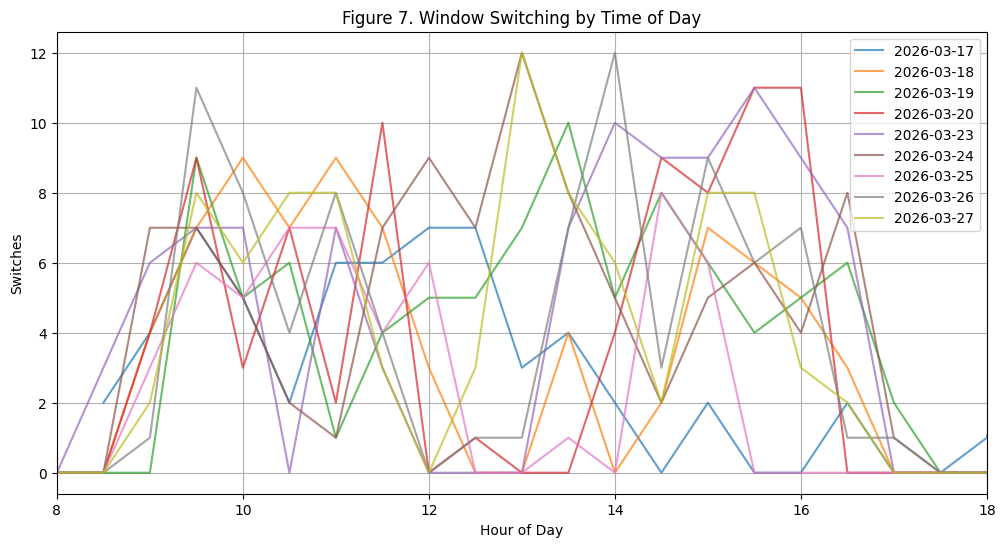

In [203]:
plt.figure(figsize=(12, 6))

for day, series in daily_groups:
    x = series.index.hour + series.index.minute / 60
    plt.plot(x, series.values, label=str(day), alpha=0.7)

plt.title('Window Switches Over Time')
plt.xlabel('Time of Day')
plt.ylabel('Switches')
plt.grid(True)


plt.legend()
plt.title('Figure 7. Window Switching by Time of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Switches')
plt.grid(True)

plt.xlim(8, 18)
plt.show()